# Credit Card Fraud Detection using Machine Learning

This project aims to detect fraudulent credit card transactions using machine learning models. The dataset is highly imbalanced, so techniques like SMOTE are used to improve model performance.

In [ ]:
!pip install imbalanced-learn

Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.shape

(21878, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21878 entries, 0 to 21877
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    21878 non-null  int64  
 1   V1      21878 non-null  float64
 2   V2      21878 non-null  float64
 3   V3      21878 non-null  float64
 4   V4      21878 non-null  float64
 5   V5      21878 non-null  float64
 6   V6      21878 non-null  float64
 7   V7      21878 non-null  float64
 8   V8      21878 non-null  float64
 9   V9      21878 non-null  float64
 10  V10     21878 non-null  float64
 11  V11     21878 non-null  float64
 12  V12     21878 non-null  float64
 13  V13     21878 non-null  float64
 14  V14     21878 non-null  float64
 15  V15     21878 non-null  float64
 16  V16     21878 non-null  float64
 17  V17     21878 non-null  float64
 18  V18     21878 non-null  float64
 19  V19     21878 non-null  float64
 20  V20     21878 non-null  float64
 21  V21     21878 non-null  float64
 22

In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,21791
1.0,86


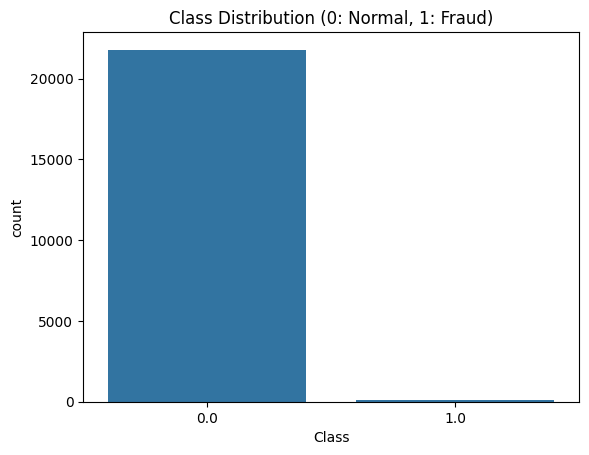

In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.show()

We can clearly see that fraud cases are extremely less compared to normal transactions, indicating a highly imbalanced dataset.

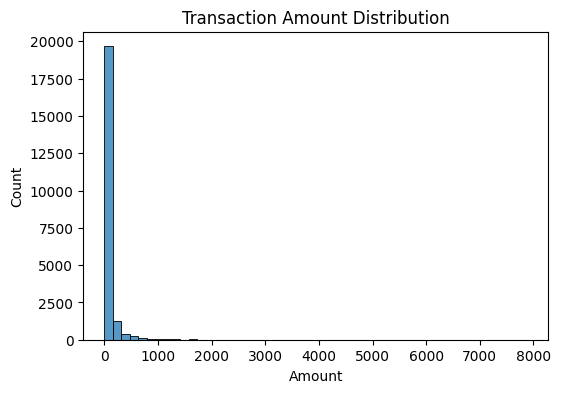

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

Most transactions are of small amounts, with very few high-value transactions.

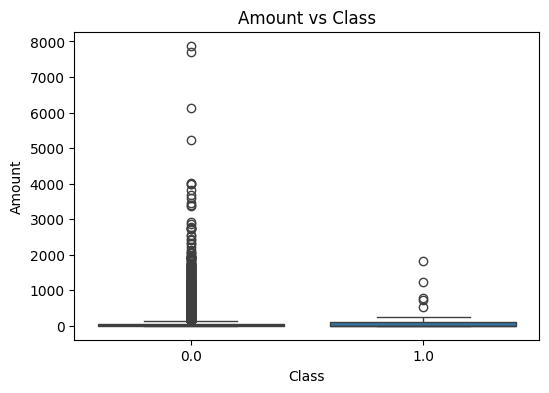

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount vs Class')
plt.show()

Fraudulent transactions tend to have different distribution patterns compared to normal ones

Checked for missing values in the dataset to ensure data completeness before preprocessing.

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

Data Cleaning

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Feature Separation

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

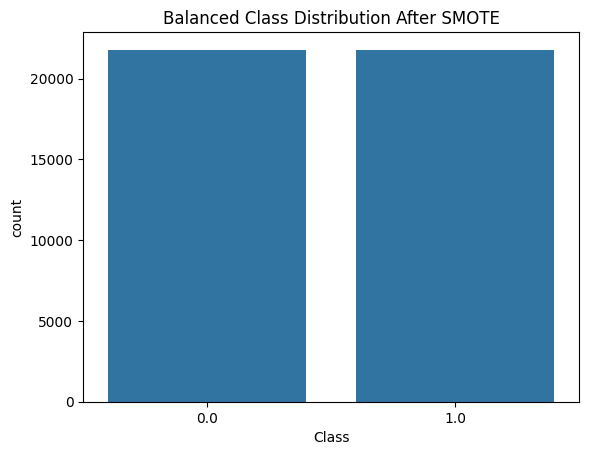

In [ ]:
sns.countplot(x=y_res)
plt.title('Balanced Class Distribution After SMOTE')
plt.show()

After applying SMOTE, both classes are balanced, which helps the model learn better

In [ ]:
y_res.value_counts()

,count
Class,
0.0,21791
1.0,21791


Train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Model Building

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, solver='liblinear')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression
[[4321   28]
 [  81 4287]]
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      4349
         1.0       0.99      0.98      0.99      4368

    accuracy                           0.99      8717
   macro avg       0.99      0.99      0.99      8717
weighted avg       0.99      0.99      0.99      8717

Random Forest
[[4349    0]
 [   0 4368]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4349
         1.0       1.00      1.00      1.00      4368

    accuracy                           1.00      8717
   macro avg       1.00      1.00      1.00      8717
weighted avg       1.00      1.00      1.00      8717



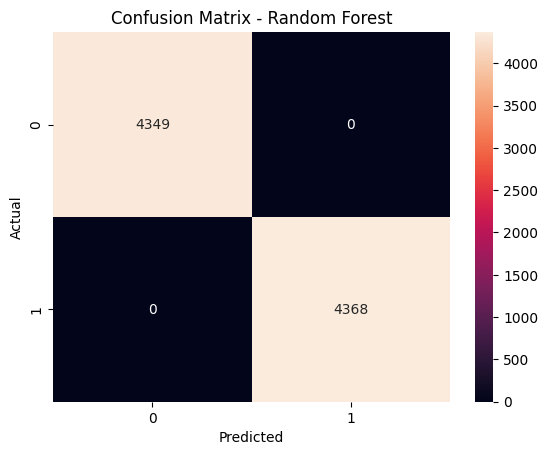

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The confusion matrix shows that the model correctly classified almost all transactions

## Conclusion

Random Forest outperformed Logistic Regression with higher accuracy and better fraud detection capability. SMOTE played a crucial role in handling class imbalance and improving model performance.